# Square-Net Materials Data Collection Pipeline

This notebook demonstrates the physics-based first stage of the project: Detecting square-net layers in crystalline solids and converting the crystal structures into reproducible, machine-learning-ready square-net data. The detector is the data-generation foundation for several research questions:

1. Does geometric and chemical information extracted from square-net motif layers improve material property prediction over typical methods?
2. To what extent can automatically extracted square-net structural and chemical descriptors reproduce existing topological semimetal classifications, and which classes of descriptors contribute most to predictive performance?  
3. Does attention-based multi-instance learning outperform traditional layer-aggregation strategies (e.g., dominant-layer selection, mean pooling, maximum pooling, and top-k pooling) for predicting material properties and topological classifications?

The square-net layer motif is relatively common in inorganic crystalline solids and serves as a proof-of-concept starting point where this concept may later be extended to other structural motifs (triangle, kagome, ladder, honeycomb, etc.).

The demonstration uses a small local cache by default. It makes no live Materials Project query and reads no credentials.

## Scientific motivation

A square net is a repeated two-dimensional atomic arrangement whose nearest in-plane neighbors are approximately equally spaced and meet at approximately 90 degrees. Such motifs are interesting from a physics standpoint as they often produce complex electronic behavior and emergent states. Some interesting phenomena include: 
* Dirac physics within a crystalline solid. These non-trivial bandstrucures found in square-net materials often result in extremely high mobility of electronic carriers, nearly massless quasiparticles, extremely large magnetoresistance, chiral anomaly, large spin Hall and spin Nerst effects.
* High temperature superconductivity 
* Charge density waves
* Topological spin textures: skyrmions, antiskyrmions, merons, hopfions

Understanding and tuning Dirac semimetals states will help us to unlock direct future applications such as stable quantum computing, low-power spintronics, ultrafast optoelectronics and photodetectors, high-efficiency thermoelectrics, and tunable terahertz communication. 

From a materials informatics standpoint, the square-net motif is interesting because layered geometry and chemical environment can be useful structural descriptors. Automated identification is nontrivial: real structures can be distorted, mixed in occupancy or species, nonorthogonal, periodic, and surrounded by competing nearby layers. Here a *candidate* square-net layer is a crystallographic plane and species with square-like local geometry, repeated in-plane connectivity, and measured coplanar and neighboring-plane context. The surrounding environment helps distinguish a geometrically regular plane from an isolated or chemically meaningful layer.

## Pipeline overview

```mermaid
flowchart LR
    A["Materials Project query or cached structure"] --> B["Structure normalization"]
    B --> C["Plane grouping"]
    C --> D["Square geometry scoring"]
    D --> E["Surrounding-environment features"]
    E --> F["Layer-level table"]
    F --> G["Axis/species-level table"]
    G --> H["Material-level table"]
```

The package normalizes the structure selected in configuration, groups axis-normal planes with periodic boundaries, scores local in-plane geometry, then retains adjacent-plane, coplanar-chemistry, and optional CrystalNN descriptors. Aggregation happens only after raw layer records are retained.

## Environment setup

Run this notebook from a clone of the repository after installing its dependencies:

```bash
git clone https://github.com/cookms/squarenet_ml.git
cd squarenet_ml
python -m venv .venv
# Activate the environment, then:
pip install -r requirements.txt
jupyter lab
```

For the optional Materials Project section, store the key in an environment variable rather than in the notebook:

```bash
export MP_API_KEY="your-key"
```

On PowerShell:

```powershell
$env:MP_API_KEY = "your-key"
```

## Import modules 

In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from typing import Any, Iterable
from dataclasses import asdict, is_dataclass
from IPython.display import Markdown, display
from pymatgen.core import Lattice, Structure

os.chdir('..')
REPO_ROOT = Path.cwd().resolve()
print(f"Current working directory: {REPO_ROOT}")

OUTPUT_ROOT = REPO_ROOT / "outputs" / "data_collection_demo"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Notebook outputs will be written to: {OUTPUT_ROOT}")

from squarenet.detect import find_square_net_planes
from squarenet.visualization import plot_detection_summary

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Current working directory: C:\Users\mscoo\GIT_projects\Squarenet_ML
Notebook outputs will be written to: C:\Users\mscoo\GIT_projects\Squarenet_ML\outputs\data_collection_demo


# 1. Deterministic detector validation

We first create several local controlled structures:

- **Ideal square net:** equal in-plane lattice constants and 90 degree angles.
- **Nearly square angle:** the angle gamma defined between a and b is slightly less than 90 degrees. 
- **Nearly square length:** one in-plane lattice constant is stretched, breaking the equal-neighbor-length condition.
- **Nearly square combined:** both the angle and lengths are slightly distorted from a perfect square.
- **Rectangular failure:** one in-plane lattice constant is much larger than the other.
- **Angular failure:** the angle between a and b lattice vectors is far from 90 degrees.
- **Combined failure:** both the angle and lengths are heavily distorted to be clearly non-square.

Both structures contain a Si layer separated from a Ca spacer layer. The detector is restricted to the Si species and the crystallographic `c` axis so that the comparison isolates the intended geometric perturbation.

In [2]:
#Function to create simple test structures 

def make_layered_test_structure(
    a: float,
    b: float,
    c: float,
    alpha: float = 90.0,
    beta: float = 90.0,
    gamma: float = 90.0,
    in_plane_repeat: tuple[int, int, int] = (2, 2, 1),
) -> Structure:
    """Build a layered Si/Ca test structure with a tunable Si-plane metric.

    The Si atoms form a two-dimensional Bravais net in the a-b plane.

    Parameters
    ----------
    a, b, c
        Lattice-vector lengths in angstroms.
    alpha
        Angle between b and c, in degrees.
    beta
        Angle between a and c, in degrees.
    gamma
        Angle between a and b, in degrees. This controls the in-plane
        angle of the Si net.
    in_plane_repeat
        Supercell transformation applied after constructing the unit cell.
    """
    lattice = Lattice.from_parameters(
        a=a,
        b=b,
        c=c,
        alpha=alpha,
        beta=beta,
        gamma=gamma,
    )

    structure = Structure(
        lattice=lattice,
        species=["Si", "Ca"],
        coords=[
            [0.0, 0.0, 0.5],  # candidate Si layer
            [0.5, 0.5, 0.0],  # chemically distinct spacer layer
        ],
        coords_are_cartesian=False,
    )

    structure.make_supercell(in_plane_repeat)
    return structure


structures = {
    # Exact square net:
    # a = b and gamma = 90 degrees.
    "ideal_square": make_layered_test_structure(a=3.35, b=3.35, c=9.0, gamma=90.0),

    # Equal neighbor distances, but slightly non-square angles.
    # This is a rhombic distortion.
    "nearly_square_angle": make_layered_test_structure(a=3.35, b=3.35, c=9.0, gamma=88.0),

    # Slightly unequal neighbor distances but exact right angles.
    # This is a weak rectangular distortion.
    "nearly_square_lengths": make_layered_test_structure(a=3.35, b=3.45, c=9.0, gamma=90.0),

    # Both the lengths and angles are slightly distorted.
    "nearly_square_combined": make_layered_test_structure(a=3.35, b=3.45, c=9.0, gamma=88.0),

    # Clear rectangular failure:
    # right angles, but strongly unequal neighbor distances.
    "rectangular_failure": make_layered_test_structure(a=3.35, b=3.75, c=9.0, gamma=90.0),

    # Equal bond lengths but a clearly non-square in-plane angle.
    "angular_failure": make_layered_test_structure(a=3.35, b=3.35, c=9.0, gamma=80.0),

    # Both criteria should clearly fail.
    "combined_failure": make_layered_test_structure(a=3.35, b=4.0, c=9.0, gamma=85.0),
}

structure_overview = pd.DataFrame(
    [
        {
            "example": name,
            "formula": structure.composition.reduced_formula,
            "n_sites": len(structure),
            "a_A": structure.lattice.a,
            "b_A": structure.lattice.b,
            "c_A": structure.lattice.c,
            "b_over_a": structure.lattice.b / structure.lattice.a,
        }
        for name, structure in structures.items()
    ]
)
structure_overview

,example,formula,n_sites,a_A,b_A,c_A,b_over_a
0,ideal_square,CaSi,8,6.7,6.7,9.0,1.000000
1,nearly_square_angle,CaSi,8,6.7,6.7,9.0,1.000000
2,nearly_square_lengths,CaSi,8,6.7,6.9,9.0,1.029851
3,nearly_square_combined,CaSi,8,6.7,6.9,9.0,1.029851
4,rectangular_failure,CaSi,8,6.7,7.5,9.0,1.119403
5,angular_failure,CaSi,8,6.7,6.7,9.0,1.000000
6,combined_failure,CaSi,8,6.7,8.0,9.0,1.194030


## Detector workflow

### For each requested axis, the function:

1. Groups atoms into periodic planes using fractional-coordinate tolerance plane_tol=0.01.
2. Constructs a two-dimensional basis for each plane.
3. Separately evaluates every chemical species present in the plane.
4. Tiles the plane periodically so atoms near unit-cell boundaries have the correct in-plane neighbors.
5. Scores the local environment around every target-species atom for square-like geometry.
6. Measures nearest-neighbor distances inside the candidate layer.
7. Identifies the preceding and following adjacent planes.
8. Measures candidate-to-adjacent-plane atom distances and plane-center separations.
9. Uses CrystalNN to calculate coordination, bonding, species, and bond-angle features.
10. Applies the primary passes screen.
11. Applies the stricter passes2 screen.
12. Returns all candidates by default, including failures, sorted with the strongest primary candidates first.

In [3]:
#Set detector kwargs for demo usage

DETECTOR_KWARGS = dict(
    axes=("c",),
    species=("Si",),
    plane_tol=0.02,
    k_nn=9,
    len_tol=0.10,
    ang_tol_deg=5.0,
    min_pass_fraction=0.50,
    score_threshold=0.70,
    return_all=True,
    preserve_visualization_data=True,
    adjacent_by="atom",
    nn_intra_min_max=5.5,
    min_adj_dist_any_atom_min=2.0,
    forbid_coplane_mixed_species=True,
    isolate_same_species_adjacent=True,
    isolate_same_species_adjacent_dist_min=2.0,
    # Keep the synthetic geometry test fast and independent of oxidation-state guessing.
    enforce_no_out_of_plane_same_species_bonds=False,
    compute_crystalnn_features=False,
)


def result_to_record(result: Any, *, include_visualization: bool = False) -> dict[str, Any]:
    """Convert a detector result to a dictionary without recursively copying plot arrays."""
    record = dict(vars(result))
    if not include_visualization:
        record.pop("visualization_data", None)
    return record

def results_to_frame(results: Iterable[Any]) -> pd.DataFrame:
    return pd.DataFrame([result_to_record(result) for result in results])

raw_results = {
    name: find_square_net_planes(structure, **DETECTOR_KWARGS)
    for name, structure in structures.items()
}

for name, results in raw_results.items():
    print(f"{name}: {len(results)} candidate layer record(s)")

ideal_square: 1 candidate layer record(s)
nearly_square_angle: 1 candidate layer record(s)
nearly_square_lengths: 1 candidate layer record(s)
nearly_square_combined: 1 candidate layer record(s)
rectangular_failure: 1 candidate layer record(s)
angular_failure: 1 candidate layer record(s)
combined_failure: 1 candidate layer record(s)


In [4]:
layer_frames = []
for example, results in raw_results.items():
    frame = results_to_frame(results)
    frame.insert(0, "example", example)
    layer_frames.append(frame)
    
synthetic_layers = pd.concat(layer_frames, ignore_index=True)

preferred_columns = [
    "example",
    "axis",
    "plane_id",
    "species",
    "n_sites",
    "passes",
    "passes2",
    "pass_fraction",
    "mean_score",
    "median_score",
    "nn_intra_min",
    "nn_intra_mean",
    "tol_ratio_any",
    "uv_len_err_mean",
    "uv_ang_deg_mean",
    "min_adj_dist_any_atom",
    "passes2_fail_reasons",
]
visible_columns = [column for column in preferred_columns if column in synthetic_layers.columns]
synthetic_layers[visible_columns].sort_values("mean_score", ascending=False)

,example,axis,plane_id,species,n_sites,passes,passes2,pass_fraction,mean_score,median_score,nn_intra_min,nn_intra_mean,tol_ratio_any,uv_len_err_mean,uv_ang_deg_mean,min_adj_dist_any_atom,passes2_fail_reasons
0,ideal_square,c,1,Si,4,True,True,1.0,1.000000,1.000000,3.35,3.35,0.658749,0.000000e+00,90.0,5.085396,[]
2,nearly_square_lengths,c,1,Si,4,True,True,1.0,0.917131,0.917131,3.35,3.35,0.656595,2.941176e-02,90.0,5.102083,[]
1,nearly_square_angle,c,1,Si,4,True,True,1.0,0.852144,0.852144,3.35,3.35,0.661258,6.628197e-17,90.0,5.066105,[]
3,nearly_square_combined,c,1,Si,4,True,True,1.0,0.781527,0.781527,3.35,3.35,0.659153,2.941176e-02,91.0,5.082280,[]
4,rectangular_failure,c,1,Si,4,False,False,0.0,0.280947,0.280947,3.35,3.35,0.649888,1.126761e-01,90.0,5.154731,[primary_pass_failed]
5,angular_failure,c,1,Si,4,False,False,0.0,0.018316,0.018316,3.35,3.35,0.671521,6.628197e-17,90.0,4.988674,[primary_pass_failed]
6,combined_failure,c,1,Si,4,False,False,0.0,0.016110,0.016110,3.35,3.35,0.651110,1.768707e-01,87.5,5.145064,[primary_pass_failed]


### Expected interpretation

The ideal structure should rank above the various length and angle distortions because the detector rewards four approximately equivalent in-plane neighbors arranged along two orthogonal directions. The comparison is more informative than a single positive example: it tests whether the score changes in the physically expected direction under controlled perturbations.

`passes` reflects the primary geometric screen. `passes2` starts from that result and applies additional distance, composition, and optional bonding constraints that reflect important features that are common in square net topological semimetals such as isolated single species square net layers.

## Local square-site scoring

Each candidate atom is scored by how closely its projected neighbor environment resembles a square.

1. The nearby atoms are sorted by in-plane distance, and up to the eight closest neighbors are considered.
2. The nearest neighbor defines one direction, $\mathbf{u}$.
3. The first sufficiently non-collinear neighbor defines a second direction, $\mathbf{v}$.
4. The site must also contain neighbors near both opposite directions, $-\mathbf{u}$ and $-\mathbf{v}$. If either is missing, the score is set to zero.
5. For a complete four-direction environment, the score penalizes:

   * unequal lengths $d_u$ and $d_v$,
   * deviation of the angle $\theta$ from $90^\circ$.


$\epsilon_{\mathrm{len}} = \frac{|d_u-d_v|}{(d_u+d_v)/2} $
=======================
$\epsilon_{\mathrm{ang}}$ = $|\theta-90^\circ|$
=======================

$S_{\mathrm{site}}=\exp\left[-\left(\frac{\epsilon_{\mathrm{len}}}{\mathrm{len_tol}}\right)^2-\left(\frac{\epsilon_{\mathrm{ang}}}{\mathrm{ang_tol}}\right)^2\right]$
=================

The score ranges from 0 to 1. A score near 1 represents four nearly equally spaced neighbors arranged at right angles, while distorted or incomplete environments receive lower scores.


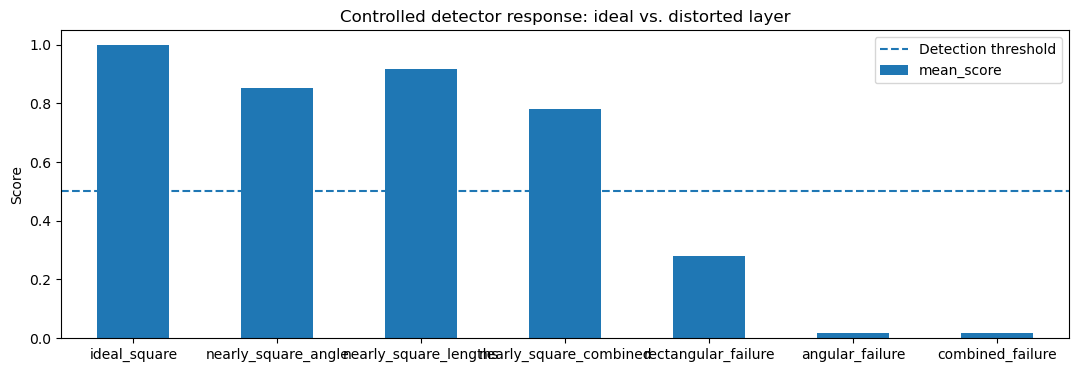

In [5]:
synthetic_layers_sorted = synthetic_layers.sort_values(
    by="mean_score",
    ascending=False,
)

ax = synthetic_layers.plot(
    x="example",
    y=["mean_score"],
    kind="bar",
    figsize=(13, 4),
    rot=0,
    title="Controlled detector response: ideal vs. distorted layer",
)
ax.axhline(
    y=0.5,
    linestyle="--",
    linewidth=1.5,
    label="Detection threshold",
)

ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend()
#plt.tight_layout()
plt.show()


## Detector explanation plot

The visualization module can show the projected candidate layer, selected in-plane neighbors, local scores, and nearby planes. This is valuable for both scientific debugging and model interpretability: a candidate should not be accepted solely because a scalar score is high.

C:\Users\mscoo\GIT_Projects\Squarenet_ML\squarenet\visualization.py:1869: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(
C:\Users\mscoo\GIT_Projects\Squarenet_ML\squarenet\visualization.py:780: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(right=0.76)


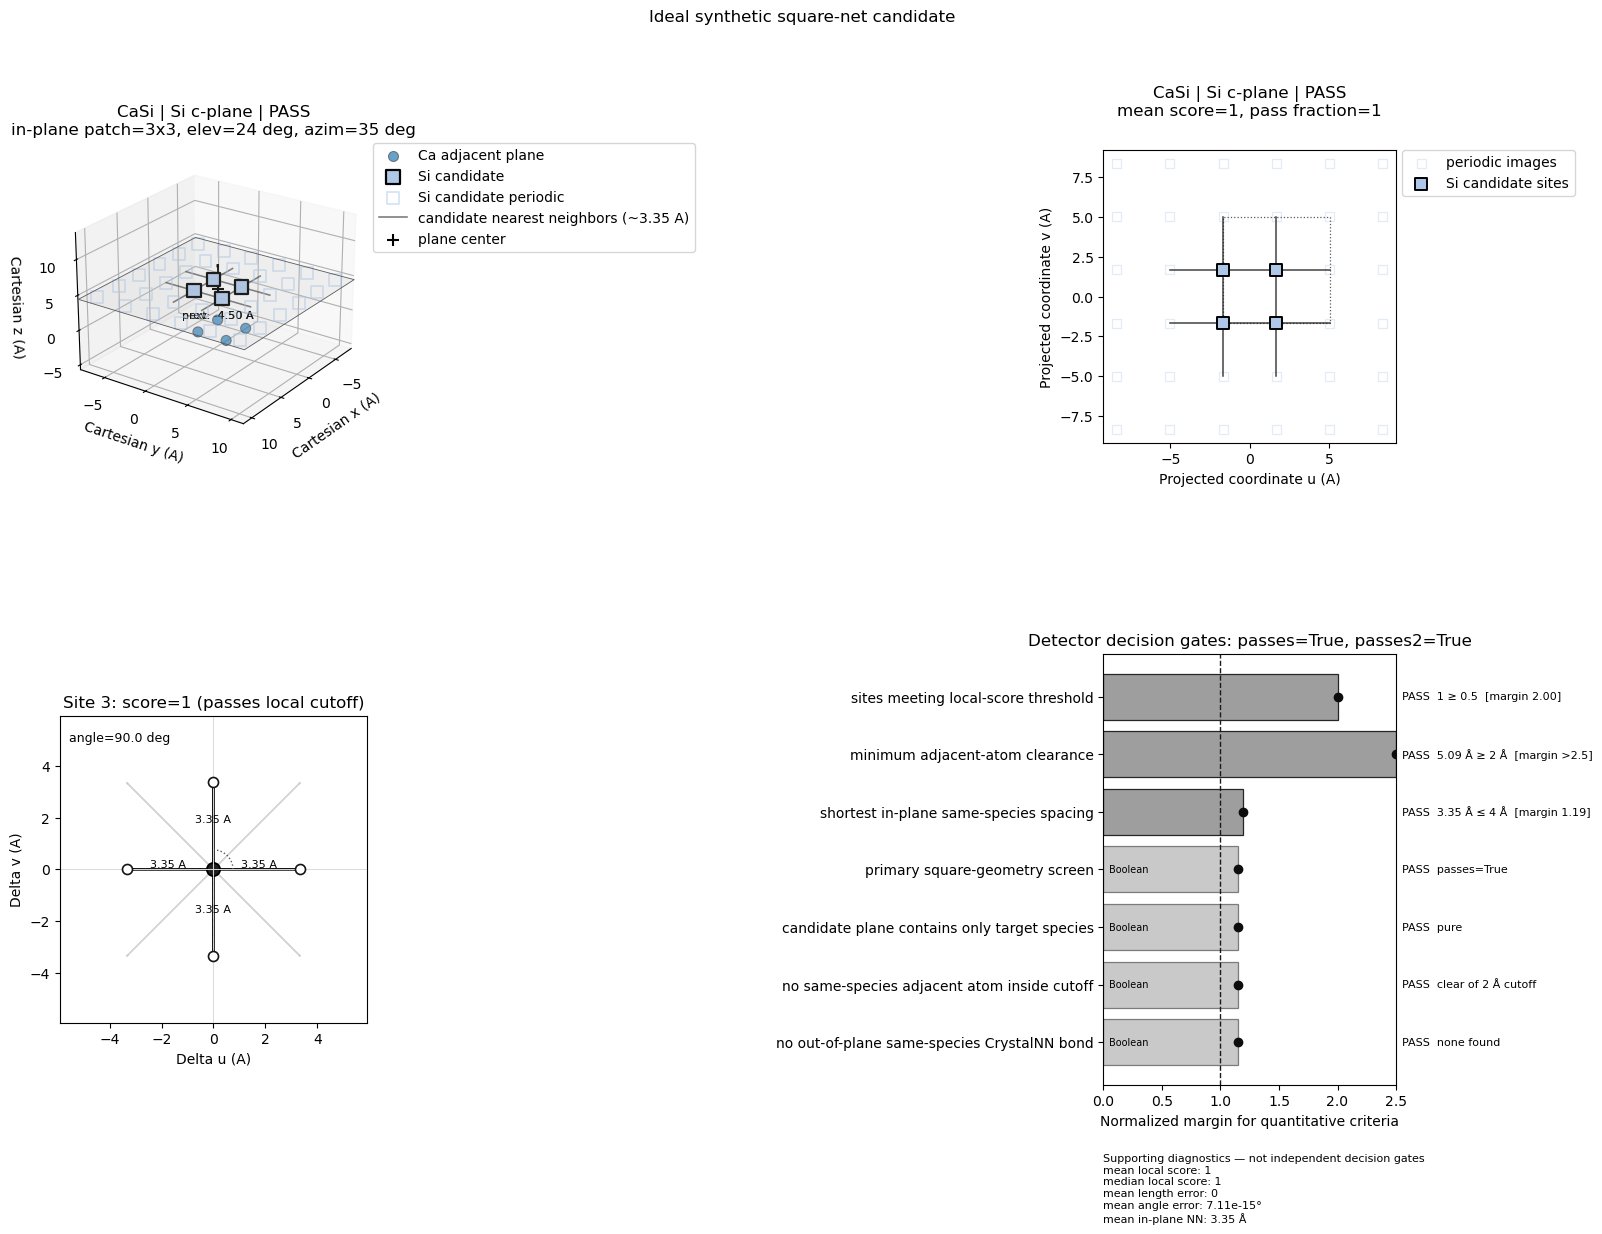

In [6]:
def best_result(results: list[Any]) -> Any:
    def rank_key(result: Any) -> tuple[int, float]:
        score = float(getattr(result, "mean_score", float("-inf")))
        if not np.isfinite(score):
            score = float("-inf")
        return int(bool(getattr(result, "passes2", False))), score

    return max(results, key=rank_key)


if raw_results["ideal_square"]:
    ideal_best = best_result(raw_results["ideal_square"])
    fig, _axes = plot_detection_summary(
        structures["ideal_square"],
        ideal_best,
        representative_site="worst",
    )
    fig.suptitle("Ideal synthetic square-net candidate", y=1.02)
    plt.show()
else:
    print("No ideal-square candidates were returned; inspect detector settings before plotting.")

# 2. What information is collected?

The detector creates a rich layer representation rather than a single binary label.

| Feature family | Representative fields | Scientific role |
|---|---|---|
| Square geometry | `mean_score`, `pass_fraction`, `uv_len_err_mean`, `uv_ang_deg_mean` | Quantifies how closely a candidate resembles a 2D square lattice |
| Intralayer scale | `nn_intra_min`, `nn_intra_mean`, `tol_ratio_any` | Characterizes net size and geometric tolerance |
| Layer isolation | `min_adj_dist_any_atom`, `min_adj_dist_any_plane`, plane separation metrics | Distinguishes isolated nets from 3D-connected motifs |
| Co-plane chemistry | species counts, major-species fraction, mixed-plane flags | Captures chemical purity and substitution within the candidate layer |
| Adjacent-layer chemistry | nearest-plane species counts and identities | Encodes the local chemical environment surrounding the net |
| CrystalNN bonding | coordination, in-plane/out-of-plane neighbor species, bond lengths and angles | Adds chemically informed connectivity beyond pure geometry |
| Screening labels | `passes`, `passes2`, failure reasons | Supports supervised detector emulation, auditing, and threshold studies |

This representation enables explicit feature-ablation experiments: composition-only, global-structure, layer-geometry, layer-chemistry, and combined models.

# 3. Optional Materials Project data collection

The next section demonstrates the repository's production workflow:

1. query selected Materials Project summaries,
2. fetch structures,
3. standardize the structure used for detection,
4. detect and summarize candidate layers,
5. write `materials.csv`, `axis_species.csv`, `meta.json`, and a processed-ID log.

The demo uses the repository's `mpids.txt` when available. Those IDs are suitable as smoke tests, not as a scientifically balanced benchmark. A final study should construct a documented cohort with known positives, hard negatives, composition controls, and prototype-aware splits.

In [7]:
#import detector pipeline 
from squarenet.config import (
    DetectConfig,
    MPQueryConfig,
    OutputConfig,
    PipelineConfig,
    PreprocessConfig,
)
from squarenet.pipeline import run_pipeline

#small function to read demo materials project id file
def read_material_ids(path: Path) -> list[str]:
    if not path.exists():
        return []
    ids = []
    for line in path.read_text(encoding="utf-8").splitlines():
        stripped = line.strip()
        if stripped and not stripped.startswith("#"):
            ids.append(stripped)
    return ids


RUN_MP_DEMO = True  # Deliberate safety switch: set True only when ready.
MP_API_KEY = os.environ.get("MP_API_KEY") or os.environ.get("MAPI_KEY")
DEMO_MATERIAL_IDS = read_material_ids(REPO_ROOT / "mpids.txt") or ["mp-149", "mp-13"]
MP_OUTPUT_DIR = OUTPUT_ROOT / "materials_project_demo"

print(f"Materials Project key detected: {bool(MP_API_KEY)}")
print(f"Demo IDs: {DEMO_MATERIAL_IDS}")

Materials Project key detected: True
Demo IDs: ['mp-149', 'mp-13', 'mp-975411', 'mp-1102688', 'mp-4374', 'mp-667273', 'mp-10816', 'mp-989557']


In [8]:
mp_demo_config = PipelineConfig(
    mp=MPQueryConfig(
        api_key=MP_API_KEY,
        material_ids=DEMO_MATERIAL_IDS,
        limit=len(DEMO_MATERIAL_IDS),
    ),
    preprocess=PreprocessConfig(
        # Conventional cells make this small notebook demo fast and transparent.
        # A production sweep can switch to "processed" and configure a supercell.
        structure_source="conventional",
        to_conventional=True,
        symprec=1e-3,
        angle_tolerance=5.0,
        supercell=None,
        sym_supercell=None,
    ),
    detect=DetectConfig(
        species=None,
        axes=("c", "a", "b"),
        plane_tol=0.01,
        k_nn=9,
        len_tol=0.10,
        ang_tol_deg=5.0,
        min_pass_fraction=0.55,
        score_threshold=0.50,
        return_all=True,
        preserve_visualization_data=False,
        adjacent_by="atom",
        nn_intra_min_max=4.0,
        min_adj_dist_any_atom_min=2.0,
        forbid_coplane_mixed_species=True,
        isolate_same_species_adjacent=True,
        isolate_same_species_adjacent_dist_min=3.0,
        enforce_no_out_of_plane_same_species_bonds=True,
        compute_crystalnn_features=True,
        crystalnn_weight_cutoff=0.0,
    ),
    output=OutputConfig(
        out_dir=str(MP_OUTPUT_DIR),
        write_csv=True,
        # CSV is sufficient for a two-material demo and avoids requiring optional pyarrow.
        write_parquet=False,
        resume=True,
        skip_existing=True,
        export_cifs=False,
        flush_every=1,
    ),
    meta={
        "notebook": "01_square_net_data_collection_demo.ipynb",
        "purpose": "portfolio data-collection demonstration",
        "random_state": RANDOM_STATE,
    },
)



In [9]:
if RUN_MP_DEMO:
    if not MP_API_KEY:
        raise RuntimeError(
            "RUN_MP_DEMO is True, but no API key was found. "
            "Set MP_API_KEY in the environment and restart the kernel."
        )
    materials_df, axis_species_df = run_pipeline(mp_demo_config)
else:
    print("Materials Project collection skipped. Set RUN_MP_DEMO = True to execute it.")
    materials_path = MP_OUTPUT_DIR / "materials.csv"
    axis_species_path = MP_OUTPUT_DIR / "axis_species.csv"
    materials_df = pd.read_csv(materials_path) if materials_path.exists() else pd.DataFrame()
    axis_species_df = pd.read_csv(axis_species_path) if axis_species_path.exists() else pd.DataFrame()

print(f"materials_df shape: {materials_df.shape}")
print(f"axis_species_df shape: {axis_species_df.shape}")

Retrieving SummaryDoc documents:   0%|          | 0/100 [00:00<?, ?it/s]

materials_df shape: (16, 51)
axis_species_df shape: (138, 44)


In [10]:
materials_df

,material_id,formula,n_layers_total,n_axes,n_species,n_pass,pass_fraction_total,has_any_pass,dominant_has_pass,dominant_axis,dominant_species,dominant_plane_id,dominant_plane_center_frac,dominant_passes2_fail_reasons,dominant_mean_score,dominant_tol_ratio_any,dominant_nn_intra_min,dominant_min_adj_dist_any_atom,dominant_uv_ang_deg_mean,dominant_uv_ang_err_mean,dominant_uv_len_err_mean,dominant_cnn_in_plane_bond_angle_deg_mean,dominant_cnn_out_of_plane_tilt_angle_deg_mean,dominant_coplane_species_counts_json,dominant_coplane_n_species,dominant_coplane_major_species,dominant_coplane_major_fraction,dominant_coplane_other_species_counts_json,dominant_coplane_other_n_species,dominant_coplane_other_fraction,dominant_cnn_out_of_plane_nn_species,dominant_cnn_out_of_plane_nn_dist,dominant_cnn_out_of_plane_bonded_species_counts_json,dominant_cnn_out_of_plane_bonded_major_species,dominant_cnn_out_of_plane_bonded_major_fraction,dominant_cnn_out_of_plane_bonded_n_species,dominant_square_species_oxi_state_mean,dominant_square_species_oxi_state_std,dominant_has_out_of_plane_same_species_bond,dominant_adj_atom_plane_major_species,dominant_adj_atom_plane_major_fraction,dominant_adj_atom_plane_species_counts_json,dominant_adj_plane_plane_major_species,dominant_adj_plane_plane_major_fraction,dominant_adj_plane_plane_species_counts_json,structure_source,sg_number,sg_symbol,crystal_system,energy_above_hull,band_gap
0,mp-975411,RbBr3,14,3,2,2,0.142857,1,1,c,Br,1,0.250000,NaN,1.000000e+00,0.812353,3.194096,3.931906,90.000000,7.105427e-15,2.085516e-16,NaN,54.940941,"{""Br"": 2}",1,Br,1.000000,{},0,NaN,Rb,3.931906,"{""Rb"": 8}",Rb,1.000000,1,NaN,NaN,0,Rb,0.500000,"{""Br"": 1, ""Rb"": 1}",Rb,0.500000,"{""Br"": 1, ""Rb"": 1}",conventional,139,I4/mmm,Tetragonal,0.000000,0.0000
1,mp-1102688,PrSbSe,28,3,3,2,0.071429,1,1,b,Sb,5,0.500000,NaN,6.233557e-01,0.832366,2.875223,3.454276,93.126510,3.126510e+00,2.857193e-02,91.586582,52.163412,"{""Sb"": 2}",1,Sb,1.000000,{},0,NaN,Pr,3.454276,"{""Pr"": 8}",Pr,1.000000,1,-1.000000,0.0,0,Pr,1.000000,"{""Pr"": 1}",Pr,1.000000,"{""Pr"": 1}",conventional,14,P2_1/c,Monoclinic,0.000000,0.0000
2,mp-149,Si,12,3,1,0,0.000000,0,0,c,Si,2,0.500000,out_of_plane_same_species_bond,1.000000e+00,1.632993,3.849279,2.357192,90.000000,7.105427e-15,1.730542e-16,NaN,35.264390,"{""Si"": 2}",1,Si,1.000000,{},0,NaN,Si,2.357192,"{""Si"": 8}",Si,1.000000,1,0.000000,0.0,1,Si,1.000000,"{""Si"": 2}",Si,1.000000,"{""Si"": 2}",conventional,227,Fd-3m,Cubic,0.000000,0.6103
3,mp-13,Fe,6,3,1,0,0.000000,0,0,a,Fe,0,0.000000,out_of_plane_same_species_bond,9.994774e-01,1.155844,2.863964,2.477811,89.885681,1.143185e-01,0.000000e+00,NaN,35.265082,"{""Fe"": 2}",1,Fe,1.000000,{},0,NaN,Fe,2.477811,"{""Fe"": 16}",Fe,1.000000,1,0.000000,0.0,1,Fe,1.000000,"{""Fe"": 2}",Fe,1.000000,"{""Fe"": 2}",conventional,229,Im-3m,Cubic,0.000000,0.0000
4,mp-10816,NdAgAs2,18,3,3,2,0.111111,1,1,c,As,3,0.500000,NaN,1.000000e+00,0.901456,2.850346,3.161938,90.000000,7.105427e-15,1.558018e-16,90.000000,50.399896,"{""As"": 2}",1,As,1.000000,{},0,NaN,Nd,3.161938,"{""Nd"": 8}",Nd,1.000000,1,-3.000000,0.0,0,Nd,1.000000,"{""Nd"": 1}",Nd,1.000000,"{""Nd"": 1}",conventional,129,P4/nmm,Tetragonal,0.011808,0.0000
5,mp-989557,YTcN3,22,3,3,6,0.272727,1,1,b,N,0,0.010162,NaN,9.696286e-01,1.962213,3.995648,2.036296,90.000000,1.421085e-14,1.756195e-02,NaN,3.149653,"{""N"": 1}",1,N,1.000000,{},0,NaN,Tc,2.036296,"{""Tc"": 2, ""Y"": 3}",Y,0.600000,2,-2.833333,0.0,0,Tc,1.000000,"{""Tc"": 1}",Tc,1.000000,"{""Tc"": 1}",conventional,38,Amm2,Orthorhombic,0.062514,0.0000
6,mp-4374,UAsS,17,3,3,5,0.294118,1,1,c,As,0,0.000000,NaN,1.000000e+00,0.901278,2.760503,3.062876,90.000000,0.000000e+00,1.608726e-16,90.000000,50.409237,"{""As"": 2}",1,As,1.000000,{},0,NaN,U,3.062876,"{""U"": 8}",U,1.000000,1,-1.000000,0.0,0,U,1.000000,"{""U"": 1}",U,1.000000,"{""U"": 1}",conventional,129,P4/nmm,Tetragonal,0.000000,0.0000
7,mp-667273,C,90,3,1,0,0.000000,0,0,b,C,19,0.660598,primary_pass_failed,0.000000e+00,0.588725,1.443042,

## Output granularity

- `materials_df`: one row per material, centered on the detector's dominant candidate layer and augmented with selected Materials Project properties.
- `axis_species_df`: one row per `(material_id, axis, species)`, centered on the best layer for that axis/species combination.
- Low-level detector results: one row per candidate layer. The synthetic section above shows this schema directly.

**Important future-MIL engineering task:** persist every low-level candidate layer from the Materials Project pipeline to a dedicated `layers.parquet` table. The current pipeline's public return value contains the material and axis/species summaries, while multi-instance learning requires the full candidate-layer bag for every material.

In [11]:
def compact_preview(df: pd.DataFrame, preferred: list[str], n: int = 8) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame({"status": ["No rows available; run the optional collection section."]})
    columns = [column for column in preferred if column in df.columns]
    return df[columns].head(n) if columns else df.head(n)


display(Markdown("### Material-level table"))
display(
    compact_preview(
        materials_df,
        [
            "material_id",
            "formula",
            "sg_symbol",
            "crystal_system",
            "has_any_pass",
            "dominant_axis",
            "dominant_species",
            "dominant_mean_score",
            "dominant_nn_intra_min",
            "energy_above_hull",
            "band_gap",
        ],
    )
)

display(Markdown("### Axis/species-level table"))
display(
    compact_preview(
        axis_species_df,
        [
            "material_id",
            "formula",
            "axis",
            "species",
            "n_layers",
            "n_pass",
            "best_layer_has_pass",
            "best_layer_mean_score",
            "best_layer_nn_intra_min",
            "energy_above_hull",
            "band_gap",
        ],
    )
)

### Material-level table

,material_id,formula,sg_symbol,crystal_system,has_any_pass,dominant_axis,dominant_species,dominant_mean_score,dominant_nn_intra_min,energy_above_hull,band_gap
0,mp-975411,RbBr3,I4/mmm,Tetragonal,1,c,Br,1.000000,3.194096,0.000000,0.0000
1,mp-1102688,PrSbSe,P2_1/c,Monoclinic,1,b,Sb,0.623356,2.875223,0.000000,0.0000
2,mp-149,Si,Fd-3m,Cubic,0,c,Si,1.000000,3.849279,0.000000,0.6103
3,mp-13,Fe,Im-3m,Cubic,0,a,Fe,0.999477,2.863964,0.000000,0.0000
4,mp-10816,NdAgAs2,P4/nmm,Tetragonal,1,c,As,1.000000,2.850346,0.011808,0.0000
5,mp-989557,YTcN3,Amm2,Orthorhombic,1,b,N,0.969629,3.995648,0.062514,0.0000
6,mp-4374,UAsS,P4/nmm,Tetragonal,1,c,As,1.000000,2.760503,0.000000,0.0000
7,mp-667273,C,Fm-3,Cubic,0,b,C,0.000000,1.443042,0.390676,1.0093


### Axis/species-level table

,material_id,formula,axis,species,n_layers,n_pass,best_layer_has_pass,best_layer_mean_score,best_layer_nn_intra_min,energy_above_hull,band_gap
0,mp-975411,RbBr3,c,Br,4,2,1,1.000000e+00,3.194096,0.0,0.0
1,mp-975411,RbBr3,c,Rb,2,0,0,1.000000e+00,4.517134,0.0,0.0
2,mp-975411,RbBr3,a,Br,2,0,0,4.528986e-08,3.931906,0.0,0.0
3,mp-975411,RbBr3,b,Br,2,0,0,4.528986e-08,3.931906,0.0,0.0
4,mp-975411,RbBr3,a,Rb,2,0,0,7.724364e-41,4.517134,0.0,0.0
5,mp-975411,RbBr3,b,Rb,2,0,0,7.724364e-41,4.517134,0.0,0.0
6,mp-1102688,PrSbSe,b,Pr,4,0,0,9.997819e-01,4.236498,0.0,0.0
7,mp-1102688,PrSbSe,b,Se,4,0,0,9.997819e-01,4.236498,0.0,0.0


# 4. Data-quality audit

Before fitting any model, verify that the table has a stable primary key, sensible dtypes, acceptable missingness, and a target distribution compatible with the planned evaluation metric. This prevents a polished model from masking a flawed dataset.

In [12]:
def audit_table(df: pd.DataFrame, name: str, key_columns: list[str]) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(
            [{
                "table": name,
                "rows": 0,
                "columns": 0,
                "duplicate_keys": np.nan,
                "missing_cells_fraction": np.nan,
                "all_null_columns": 0,
            }]
        )

    missing_keys = [column for column in key_columns if column not in df.columns]
    duplicate_keys = (
        np.nan if missing_keys else int(df.duplicated(subset=key_columns, keep=False).sum())
    )
    missing_fraction = float(df.isna().sum().sum() / max(df.size, 1))
    all_null_columns = int(df.isna().all(axis=0).sum())

    return pd.DataFrame(
        [{
            "table": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_keys": duplicate_keys,
            "missing_cells_fraction": missing_fraction,
            "all_null_columns": all_null_columns,
        }]
    )


audits = pd.concat(
    [
        audit_table(synthetic_layers, "synthetic_layers", ["example", "axis", "plane_id", "species"]),
        audit_table(materials_df, "materials", ["material_id"]),
        audit_table(axis_species_df, "axis_species", ["material_id", "axis", "species"]),
    ],
    ignore_index=True,
)
audits

,table,rows,columns,duplicate_keys,missing_cells_fraction,all_null_columns
0,synthetic_layers,7,66,0,0.242424,16
1,materials,16,51,0,0.045343,0
2,axis_species,138,44,0,0.040679,0


In [13]:
def missingness_report(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame:
    if df.empty:
        return pd.DataFrame(columns=["column", "missing_count", "missing_fraction", "dtype"])
    report = pd.DataFrame(
        {
            "column": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_fraction": df.isna().mean().values,
            "dtype": df.dtypes.astype(str).values,
        }
    )
    return report.sort_values(["missing_fraction", "missing_count"], ascending=False).head(top_n)


missingness_report(materials_df)

,column,missing_count,missing_fraction,dtype
21,dominant_cnn_in_plane_bond_angle_deg_mean,11,0.6875,float64
29,dominant_coplane_other_fraction,11,0.6875,float64
13,dominant_passes2_fail_reasons,5,0.3125,object
36,dominant_square_species_oxi_state_mean,5,0.3125,float64
37,dominant_square_species_oxi_state_std,5,0.3125,float64
0,material_id,0,0.0000,object
1,formula,0,0.0000,object
2,n_layers_total,0,0.0000,int64
3,n_axes,0,0.0000,int64
4,n_species,0,0.0000,int64


In [14]:
if not materials_df.empty and "has_any_pass" in materials_df.columns:
    balance_values = materials_df["has_any_pass"].astype("object")
    balance_values = balance_values.where(balance_values.notna(), "missing")
    class_balance = (
        balance_values
        .value_counts(dropna=False)
        .rename_axis("has_any_pass")
        .to_frame("count")
    )
    class_balance["fraction"] = class_balance["count"] / class_balance["count"].sum()
    display(class_balance)
else:
    print("Class-balance summary will appear after Materials Project data are collected.")

,count,fraction
has_any_pass,,
0,11,0.6875
1,5,0.3125


# 5. Build an initial ML-ready material table

The current pipeline directly includes `band_gap` and `energy_above_hull`. Two useful demonstration targets can be derived transparently:

- **Metallicity proxy:** `band_gap <= 1e-6 eV`.
- **Near-hull stability label:** `energy_above_hull <= 0.05 eV/atom`.

These are modeling conveniences, not universal physical definitions. The threshold must be stated, sensitivity-tested, and kept separate from the detector labels.

Formation energy is not currently propagated into the pipeline output. Adding `formation_energy_per_atom` to the Materials Project field list and output propagation is a concrete next repository enhancement.

In [15]:
def build_ml_material_table(materials: pd.DataFrame) -> pd.DataFrame:
    if materials.empty:
        return materials.copy()

    table = materials.copy()

    if "band_gap" in table.columns:
        band_gap = pd.to_numeric(table["band_gap"], errors="coerce")
        metal_proxy = pd.Series(pd.NA, index=table.index, dtype="Int64")
        known_band_gap = band_gap.notna()
        metal_proxy.loc[known_band_gap] = (band_gap.loc[known_band_gap] <= 1e-6).astype(int)
        table["target_is_metal_proxy"] = metal_proxy

    if "energy_above_hull" in table.columns:
        e_hull = pd.to_numeric(table["energy_above_hull"], errors="coerce")
        near_hull = pd.Series(pd.NA, index=table.index, dtype="Int64")
        known_e_hull = e_hull.notna()
        near_hull.loc[known_e_hull] = (e_hull.loc[known_e_hull] <= 0.05).astype(int)
        table["target_near_hull_50meV"] = near_hull

    if "material_id" in table.columns:
        table = table.drop_duplicates(subset=["material_id"], keep="last")

    return table


ml_materials = build_ml_material_table(materials_df)

identifier_columns = [
    "material_id",
    "formula",
    "sg_number",
    "sg_symbol",
    "crystal_system",
]
property_columns = [
    "energy_above_hull",
    "band_gap",
    "target_is_metal_proxy",
    "target_near_hull_50meV",
]
layer_feature_columns = [
    column
    for column in ml_materials.columns
    if column.startswith("dominant_") or column in {"n_layers_total", "n_axes", "n_species", "n_pass", "pass_fraction_total"}
]
selected_columns = [
    column
    for column in identifier_columns + property_columns + layer_feature_columns
    if column in ml_materials.columns
]

ml_materials[selected_columns].head() if selected_columns else ml_materials.head()

,material_id,formula,sg_number,sg_symbol,crystal_system,energy_above_hull,band_gap,target_is_metal_proxy,target_near_hull_50meV,n_layers_total,n_axes,n_species,n_pass,pass_fraction_total,dominant_has_pass,dominant_axis,dominant_species,dominant_plane_id,dominant_plane_center_frac,dominant_passes2_fail_reasons,dominant_mean_score,dominant_tol_ratio_any,dominant_nn_intra_min,dominant_min_adj_dist_any_atom,dominant_uv_ang_deg_mean,dominant_uv_ang_err_mean,dominant_uv_len_err_mean,dominant_cnn_in_plane_bond_angle_deg_mean,dominant_cnn_out_of_plane_tilt_angle_deg_mean,dominant_coplane_species_counts_json,dominant_coplane_n_species,dominant_coplane_major_species,dominant_coplane_major_fraction,dominant_coplane_other_species_counts_json,dominant_coplane_other_n_species,dominant_coplane_other_fraction,dominant_cnn_out_of_plane_nn_species,dominant_cnn_out_of_plane_nn_dist,dominant_cnn_out_of_plane_bonded_species_counts_json,dominant_cnn_out_of_plane_bonded_major_species,dominant_cnn_out_of_plane_bonded_major_fraction,dominant_cnn_out_of_plane_bonded_n_species,dominant_square_species_oxi_state_mean,dominant_square_species_oxi_state_std,dominant_has_out_of_plane_same_species_bond,dominant_adj_atom_plane_major_species,dominant_adj_atom_plane_major_fraction,dominant_adj_atom_plane_species_counts_json,dominant_adj_plane_plane_major_species,dominant_adj_plane_plane_major_fraction,dominant_adj_plane_plane_species_counts_json
0,mp-975411,RbBr3,139,I4/mmm,Tetragonal,0.000000,0.0000,1,1,14,3,2,2,0.142857,1,c,Br,1,0.25,NaN,1.000000,0.812353,3.194096,3.931906,90.000000,7.105427e-15,2.085516e-16,NaN,54.940941,"{""Br"": 2}",1,Br,1.0,{},0,NaN,Rb,3.931906,"{""Rb"": 8}",Rb,1.0,1,NaN,NaN,0,Rb,0.5,"{""Br"": 1, ""Rb"": 1}",Rb,0.5,"{""Br"": 1, ""Rb"": 1}"
1,mp-1102688,PrSbSe,14,P2_1/c,Monoclinic,0.000000,0.0000,1,1,28,3,3,2,0.071429,1,b,Sb,5,0.50,NaN,0.623356,0.832366,2.875223,3.454276,93.126510,3.126510e+00,2.857193e-02,91.586582,52.163412,"{""Sb"": 2}",1,Sb,1.0,{},0,NaN,Pr,3.454276,"{""Pr"": 8}",Pr,1.0,1,-1.0,0.0,0,Pr,1.0,"{""Pr"": 1}",Pr,1.0,"{""Pr"": 1}"
2,mp-149,Si,227,Fd-3m,Cubic,0.000000,0.6103,0,1,12,3,1,0,0.000000,0,c,Si,2,0.50,out_of_plane_same_species_bond,1.000000,1.632993,3.849279,2.357192,90.000000,7.105427e-15,1.730542e-16,NaN,35.264390,"{""Si"": 2}",1,Si,1.0,{},0,NaN,Si,2.357192,"{""Si"": 8}",Si,1.0,1,0.0,0.0,1,Si,1.0,"{""Si"": 2}",Si,1.0,"{""Si"": 2}"
3,mp-13,Fe,229,Im-3m,Cubic,0.000000,0.0000,1,1,6,3,1,0,0.000000,0,a,Fe,0,0.00,out_of_plane_same_species_bond,0.999477,1.155844,2.863964,2.477811,89.885681,1.143185e-01,0.000000e+00,NaN,35.265082,"{""Fe"": 2}",1,Fe,1.0,{},0,NaN,Fe,2.477811,"{""Fe"": 16}",Fe,1.0,1,0.0,0.0,1,Fe,1.0,"{""Fe"": 2}",Fe,1.0,"{""Fe"": 2}"
4,mp-10816,NdAgAs2,129,P4/nmm,Tetragonal,0.011808,0.0000,1,1,18,3,3,2,0.111111,1,c,As,3,0.50,NaN,1.000000,0.901456,2.850346,3.161938,90.000000,7.105427e-15,1.558018e-16,90.000000,50.399896,"{""As"": 2}",1,As,1.0,{},0,NaN,Nd,3.161938,"{""Nd"": 8}",Nd,1.0,1,-3.0,0.0,0,Nd,1.0,"{""Nd"": 1}",Nd,1.0,"{""Nd"": 1}"


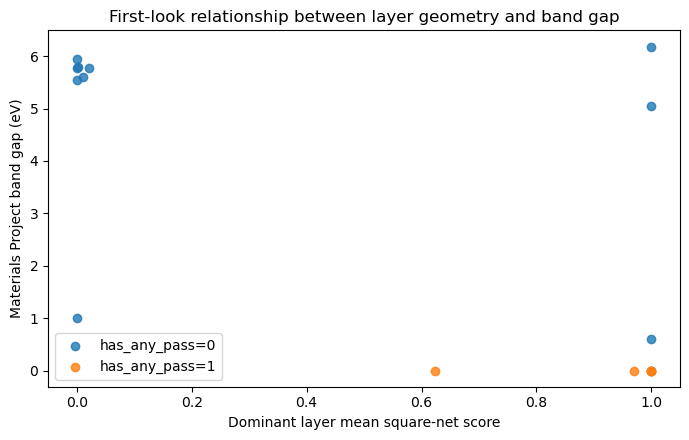

In [16]:
if not ml_materials.empty and {"dominant_mean_score", "band_gap"}.issubset(ml_materials.columns):
    plot_df = ml_materials[["dominant_mean_score", "band_gap", "has_any_pass"]].copy()
    plot_df["dominant_mean_score"] = pd.to_numeric(plot_df["dominant_mean_score"], errors="coerce")
    plot_df["band_gap"] = pd.to_numeric(plot_df["band_gap"], errors="coerce")
    plot_df = plot_df.dropna(subset=["dominant_mean_score", "band_gap"])

    fig, ax = plt.subplots(figsize=(7, 4.5))
    for label, group in plot_df.groupby("has_any_pass", dropna=False):
        ax.scatter(group["dominant_mean_score"], group["band_gap"], label=f"has_any_pass={label}", alpha=0.8)
    ax.set_xlabel("Dominant layer mean square-net score")
    ax.set_ylabel("Materials Project band gap (eV)")
    ax.set_title("First-look relationship between layer geometry and band gap")
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("The score-vs-property plot will appear after a Materials Project dataset is collected.")

In [17]:
import json

if not ml_materials.empty:
    ml_table_path = OUTPUT_ROOT / "ml_materials_demo.csv"
    schema_path = OUTPUT_ROOT / "ml_materials_demo_schema.json"

    ml_materials.to_csv(ml_table_path, index=False)
    schema = {
        "primary_key": ["material_id"],
        "n_rows": int(len(ml_materials)),
        "columns": {column: str(dtype) for column, dtype in ml_materials.dtypes.items()},
        "candidate_targets": [
            column
            for column in [
                "energy_above_hull",
                "band_gap",
                "target_is_metal_proxy",
                "target_near_hull_50meV",
            ]
            if column in ml_materials.columns
        ],
        "layer_feature_columns": layer_feature_columns,
        "notes": [
            "Metallicity and near-hull labels are notebook-derived proxies.",
            "Formation energy requires an additional Materials Project field in the repository pipeline.",
            "Full layer bags should be persisted before multi-instance learning.",
        ],
    }
    schema_path.write_text(json.dumps(schema, indent=2), encoding="utf-8")

    print(f"Wrote ML table: {ml_table_path}")
    print(f"Wrote schema:   {schema_path}")
else:
    print("No Materials Project rows are available, so only the synthetic layer table was exported.")

Wrote ML table: C:\Users\mscoo\GIT_projects\Squarenet_ML\outputs\data_collection_demo\ml_materials_demo.csv
Wrote schema:   C:\Users\mscoo\GIT_projects\Squarenet_ML\outputs\data_collection_demo\ml_materials_demo_schema.json


# 6. Machine-learning experiment roadmap

## Experiment A — Do layer descriptors improve property prediction?

Compare nested feature sets under identical splits and preprocessing:

1. **Baseline:** composition descriptors and inexpensive global crystal descriptors.
2. **Baseline + detector label:** add `has_any_pass` and dominant species/axis.
3. **Baseline + layer geometry:** add scores, in-plane distances, angle/length errors, and layer separations.
4. **Baseline + layer chemistry:** add co-plane, adjacent-plane, oxidation-state, and CrystalNN bonding summaries.
5. **Combined:** all feature families.

Targets:

- regression: band gap, energy above hull, formation energy per atom;
- classification: metal/nonmetal, near-hull stability, optional synthesized/experimental status.

Report repeated grouped cross-validation, uncertainty, and paired fold-level differences between feature sets rather than only a single best score.

## Experiment B — Can the collected descriptors reproduce topological-semimetal classifications?

Join a carefully versioned external label source to Materials Project IDs or structure-matched entries. Evaluate:

- a composition/global-structure baseline;
- square-net geometry only;
- geometry + chemical environment;
- full combined features.

Use PR-AUC and calibrated probabilities for imbalanced labels. Audit label-source coverage and structure-matching ambiguity before interpreting performance.

## Leakage-resistant evaluation design

Random row splits will overestimate performance when closely related compositions or structure prototypes appear in both train and test sets. Recommended safeguards:

- group by reduced formula, chemical system, or structure prototype;
- keep polymorphs and near-duplicate structures in the same fold;
- fit all imputers, encoders, scalers, and feature selectors inside the cross-validation pipeline;
- tune detector thresholds only on training data when the detector output itself is treated as a learned design choice;
- reserve a chemically distinct external test set for the final portfolio result;
- report bootstrap confidence intervals and feature-ablation deltas.

For topological labels, also prevent leakage from family names, hand-curated labels, or database fields that directly encode the target.